# CBAM ResNet18 Architecture

This notebook trains three positional variants of canonical CBAM (Woo et al., 2018) on top of an ImageNet-pretrained ResNet18.<br> 
CBAM applies both channel attention (using average and max pooling summed together, followed by a convolution) and spatial attention via a dual-pool convolutional map.<br> 
The three variants are: 
- cbam_end, which places a single CBAM module after the global average pool before the classifier head
- cbam_block_pre, which inserts CBAM inside every residual block before the shortcut addition
- cbam_block_post, which inserts CBAM inside every residual block after the shortcut addition and ReLU. 

<br>
Both MLP and linear head options are available for all three variants.<br>
Training follows the corrected two-phase protocol, where attention modules train alongside the classifier head in Phase 1 — this is critical because attention weights are randomly initialised and must adapt before full backbone fine-tuning begins in Phase 2. 

In [1]:
import sys
from pathlib import Path

ABSOLUTE_PATH = Path().resolve()
PROJECT_ROOT = ABSOLUTE_PATH.parents[2]
DATA_DIR = PROJECT_ROOT / "data" / "raw"
WEIGHTS_DIR = ABSOLUTE_PATH / "weights"
IMGS_DIR = ABSOLUTE_PATH / "training-imgs"

sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)
print(DATA_DIR)
print(WEIGHTS_DIR)
print(IMGS_DIR)


C:\Users\markm\Workspace\ms-machine-learning-diagnosis
C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\weights
C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\training-imgs


In [2]:
import src.scripts.data as data
import src.scripts.models as models
import src.scripts.trainer as trainer
import src.scripts.evaluator as evaluator
import src.scripts.utils as utils

# Set seed for reproducibility
utils.set_seed(42)
model_name = "cbam_end"


Random seed set to 42 for Python, NumPy, and PyTorch


## Data Acquisition & Processing

get_dataset()>>> Dataset already exists in C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
get_dataset()>>> Available categories: ['Control Axial_crop', 'Control Saggital_crop', 'MS Axial_crop', 'MS Saggital_crop']
get_classes()>>> Visualising sample images from each category...


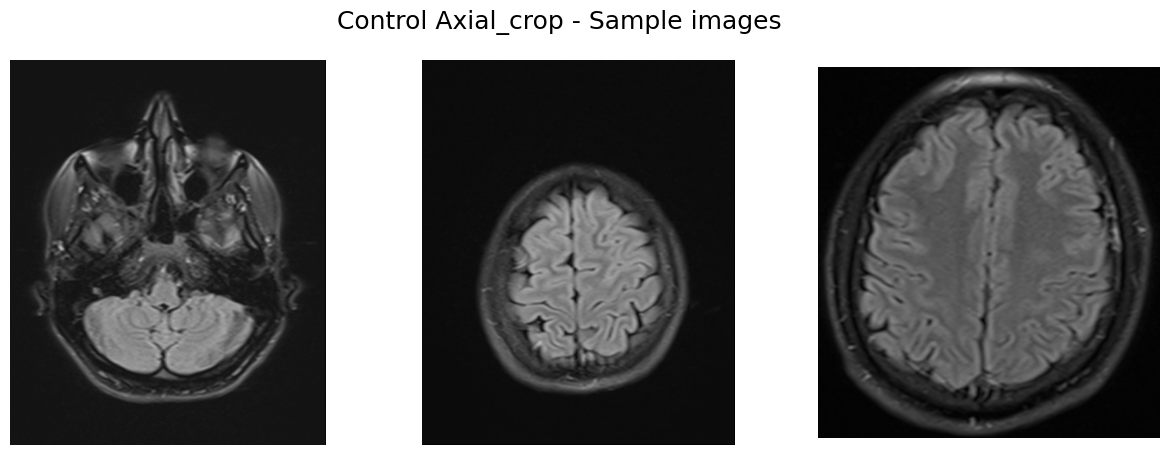

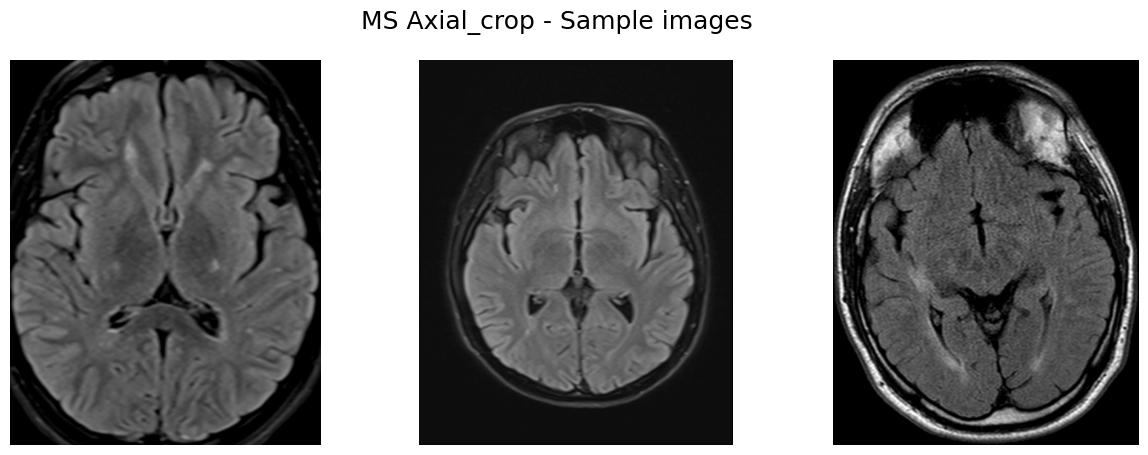

get_paths_and_labels()>>> Total images: 1652
get_data_loaders()>>> Train: 1073, Val: 248, Test: 331
get_data_loaders()>>> Proportions: Train 65.0%, Val 15.0%, Test 20.0%


In [3]:
path, categories = data.get_dataset(str(DATA_DIR))
classes = data.get_classes(path, categories)

image_paths, labels = data.get_paths_and_labels(path, classes)
train_transform, test_transform = data.get_transforms()

train_loader, val_loader, test_loader, test_data = data.get_data_loaders(
    image_paths, labels,
    train_transform, test_transform,
    val_split=0.15,
    test_split=0.20,
    batch_size=64,  # increased from 32 — better gradient estimates
    SEED=42
)


## Model Instantiation

There are several different CBAM model variations relating to different CBAM placement options. These options are as follows:
- **architecture = "cbam_end"** : Single CBAM before the classifier (after layer 4)
- **architecture = "cbam_block_pre"**: CBAM built into each BasicBlock (before the shortcut)
- **architecture = "cbam_block_post"**: CBAM built into each BasicBlock (after the shortcut)

In [4]:
# Using simplest CBAM model variation with a single CBAM module at the end of ResNet18 before classification
model = models.get_model(architecture="cbam_end")

get_model()>>> architecture='cbam_end'  head='mlp'


## Model Training

**Loss (BCEWithLogitsLoss)**: Binary cross-entropy loss combined with a sigmoid on logits. 
- Measures how well predicted probabilities match true binary labels
- Lower is better.<br>

**Loss & Acc**: Training metrics averaged over an epoch: Loss is mean training loss, Acc is training accuracy for that epoch.<br>

In [5]:
import torch.nn as nn
import torch.optim as optim

train_configs = {
    "base": {
        "num_epochs": 15,                        # increased from 10
        "lr": 1e-3,
        "weight_decay": 1e-4,                    # L2 regularisation
        "parameters": "head_and_attention",
        "optimiser": optim.AdamW,                # AdamW: decoupled weight decay
        "criterion": nn.BCEWithLogitsLoss(),
    },
    "fine_tune": {
        "num_epochs": 10,                        # increased from 5
        "lr": 1e-4,                              # increased from 1e-5 — more room to adapt
        "weight_decay": 1e-5,                    # lighter decay during fine-tune
        "parameters": "all",
        "optimiser": optim.AdamW,
        "criterion": nn.BCEWithLogitsLoss(),
    },
}



=== Phase 1: head_and_attention mode ===
TRAINABLE parameters:
  ✓ avgpool.0.ca.fc.0.weight
  ✓ avgpool.0.ca.fc.2.weight
  ✓ avgpool.0.sa.conv.weight
  ✓ fc.0.weight
  ✓ fc.0.bias
  ✓ fc.3.weight
  ✓ fc.3.bias

FROZEN parameters:
  ✗ conv1.weight
  ✗ bn1.weight
  ✗ bn1.bias
  ✗ layer1.0.conv1.weight
  ✗ layer1.0.bn1.weight
  ✗ layer1.0.bn1.bias
  ✗ layer1.0.conv2.weight
  ✗ layer1.0.bn2.weight
  ✗ layer1.0.bn2.bias
  ✗ layer1.1.conv1.weight
  ✗ layer1.1.bn1.weight
  ✗ layer1.1.bn1.bias
  ✗ layer1.1.conv2.weight
  ✗ layer1.1.bn2.weight
  ✗ layer1.1.bn2.bias
  ✗ layer2.0.conv1.weight
  ✗ layer2.0.bn1.weight
  ✗ layer2.0.bn1.bias
  ✗ layer2.0.conv2.weight
  ✗ layer2.0.bn2.weight
  ✗ layer2.0.bn2.bias
  ✗ layer2.0.downsample.0.weight
  ✗ layer2.0.downsample.1.weight
  ✗ layer2.0.downsample.1.bias
  ✗ layer2.1.conv1.weight
  ✗ layer2.1.bn1.weight
  ✗ layer2.1.bn1.bias
  ✗ layer2.1.conv2.weight
  ✗ layer2.1.bn2.weight
  ✗ layer2.1.bn2.bias
  ✗ layer3.0.conv1.weight
  ✗ layer3.0.bn1.weight
 

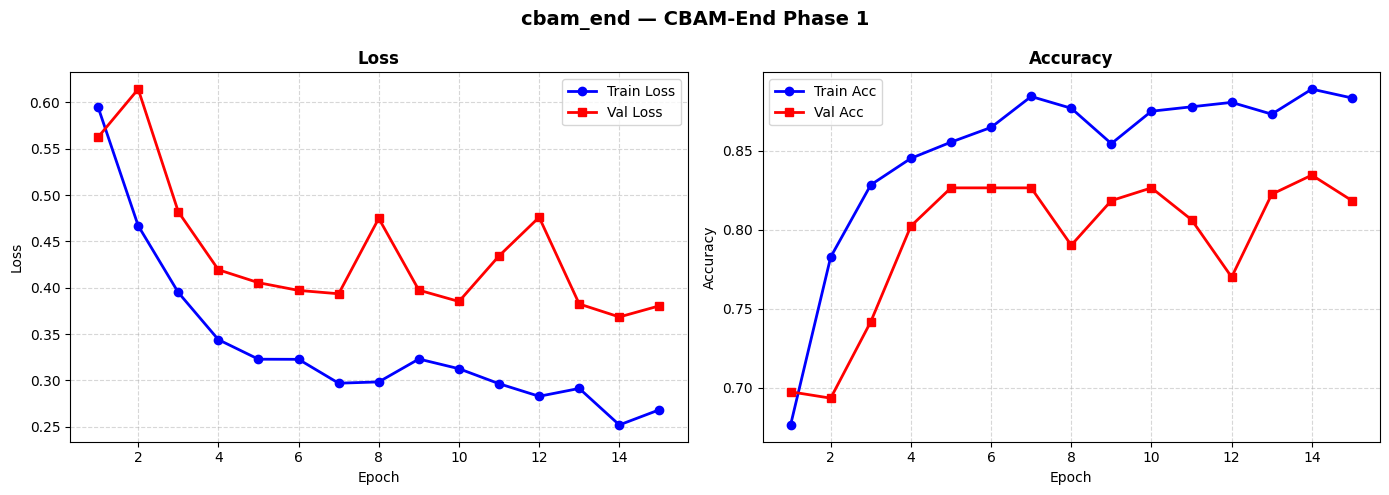

save_weights()>>> Model weights saved to C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\weights\cbam_end_base.pth


In [6]:
losses_p1, accs_p1, val_losses_p1, val_accs_p1 = trainer.train_model(
    model,
    train_loader,
    val_loader,
    config_name="base",
    train_configs=train_configs,
    verbose=True,
    early_stopping_patience=5  # increased from 3
)

utils.plot(losses_p1, accs_p1, config_name="CBAM-End Phase 1", 
     val_losses=val_losses_p1, val_accuracies=val_accs_p1,
     model_name=model_name, save_dir="training-imgs")


utils.save_weights(model, WEIGHTS_DIR / "cbam_end_base.pth")


[fine_tune] Epoch 1/10 - Train Loss: 0.2843 - Train Acc: 0.8770 - Val Loss: 0.3064 - Val Acc: 0.8750
[fine_tune] Epoch 2/10 - Train Loss: 0.1146 - Train Acc: 0.9590 - Val Loss: 0.2518 - Val Acc: 0.9032
[fine_tune] Epoch 3/10 - Train Loss: 0.0997 - Train Acc: 0.9581 - Val Loss: 0.2663 - Val Acc: 0.9194
[fine_tune] Epoch 4/10 - Train Loss: 0.0691 - Train Acc: 0.9748 - Val Loss: 0.3392 - Val Acc: 0.9153
[fine_tune] Epoch 5/10 - Train Loss: 0.0750 - Train Acc: 0.9692 - Val Loss: 0.2504 - Val Acc: 0.9355
[fine_tune] Epoch 6/10 - Train Loss: 0.0353 - Train Acc: 0.9897 - Val Loss: 0.2205 - Val Acc: 0.9194
[fine_tune] Epoch 7/10 - Train Loss: 0.0236 - Train Acc: 0.9953 - Val Loss: 0.2652 - Val Acc: 0.9395
[fine_tune] Epoch 8/10 - Train Loss: 0.0208 - Train Acc: 0.9897 - Val Loss: 0.3934 - Val Acc: 0.9073
[fine_tune] Epoch 9/10 - Train Loss: 0.0402 - Train Acc: 0.9832 - Val Loss: 0.3341 - Val Acc: 0.9274
[fine_tune] Epoch 10/10 - Train Loss: 0.0250 - Train Acc: 0.9916 - Val Loss: 0.3147 - Val A

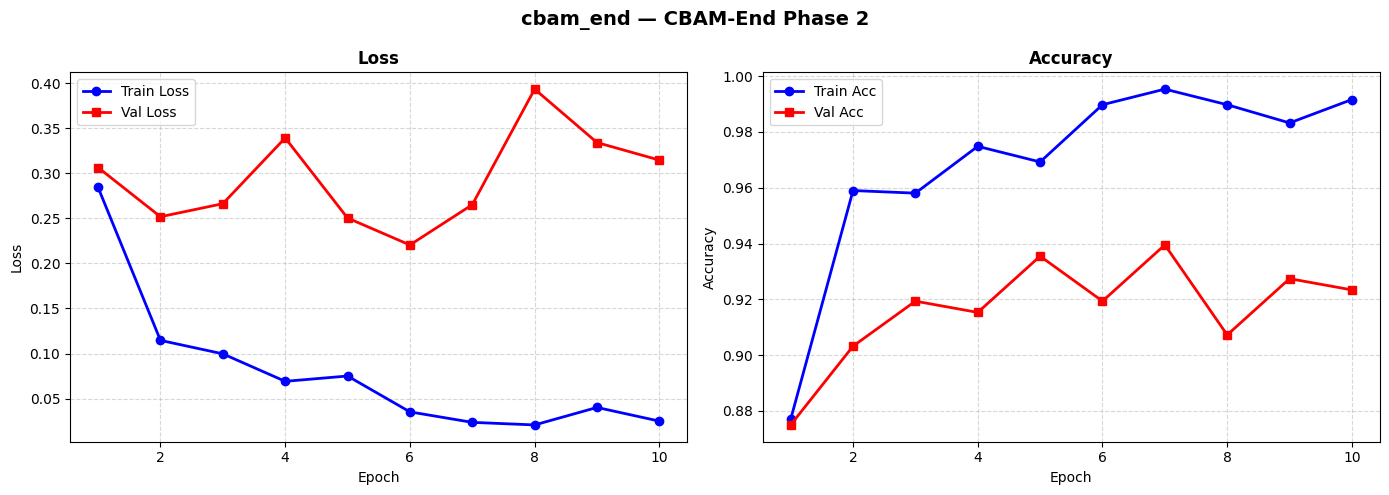

save_weights()>>> Model weights saved to C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\weights\cbam_end_fine.pth


In [7]:
losses_p2, accs_p2, val_losses_p2, val_accs_p2 = trainer.train_model(
    model,
    train_loader,
    val_loader,
    config_name="fine_tune",
    train_configs=train_configs,
    early_stopping_patience=4  # increased from 2
)

utils.plot(losses_p2, accs_p2, config_name="CBAM-End Phase 2",
     val_losses=val_losses_p2, val_accuracies=val_accs_p2,
     model_name=model_name, save_dir="training-imgs")

utils.save_weights(model, WEIGHTS_DIR / "cbam_end_fine.pth")


## Load Saved Weights
Option to load weights from previous training

In [8]:
model = models.get_model(architecture="cbam_end")
model = utils.load_weights(model, WEIGHTS_DIR / "cbam_end_fine.pth")

get_model()>>> architecture='cbam_end'  head='mlp'
load_weights()>>> Model loaded successfully and set to evaluation mode.


## Model Evaluation
**Accuracy**: Proportion of all predictions that are correct. 
- (TP + TN) / (TP + TN + FP + FN). 
- Good overall when classes are balanced.<br>

**Precision**: Of all examples predicted positive, the fraction that are actually positive. 
- TP / (TP + FP). 
- Measures false positive rate impact.<br>

**Recall (sensitivity)**: Of all actual positive examples, the fraction the model found. 
- TP / (TP + FN). 
- Measures false negative rate impact.<br>

**F1-score**: Harmonic mean of precision and recall: 
- 2 * (precision * recall) / (precision + recall). 
- Balances precision and recall.<br>

**Confusion_matrix**: 2x2 table for binary classification: 
- [[TN, FP],[FN, TP]] 
- Showing counts of true negatives, false positives, false negatives, true positives.<br>

**Classification_report**: Summary table per class containing precision, recall, f1-score and support (number of true instances for each class). 
- Also shows macro/weighted averages.<br>

In [9]:
evaluator.evaluate_model(model, test_loader)

C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\scripts\evaluator.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.float32).to(device)


Accuracy: 0.9154078549848943
Precision: 0.9180327868852459
Recall: 0.8615384615384616
Confusion Matrix:
 [[191  10]
 [ 18 112]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93       201
           1       0.92      0.86      0.89       130

    accuracy                           0.92       331
   macro avg       0.92      0.91      0.91       331
weighted avg       0.92      0.92      0.91       331



(0.9154078549848943,
 0.9180327868852459,
 0.8615384615384616,
 array([[191,  10],
        [ 18, 112]]),
 '              precision    recall  f1-score   support\n\n           0       0.91      0.95      0.93       201\n           1       0.92      0.86      0.89       130\n\n    accuracy                           0.92       331\n   macro avg       0.92      0.91      0.91       331\nweighted avg       0.92      0.92      0.91       331\n')

## Model Prediction Visualisation

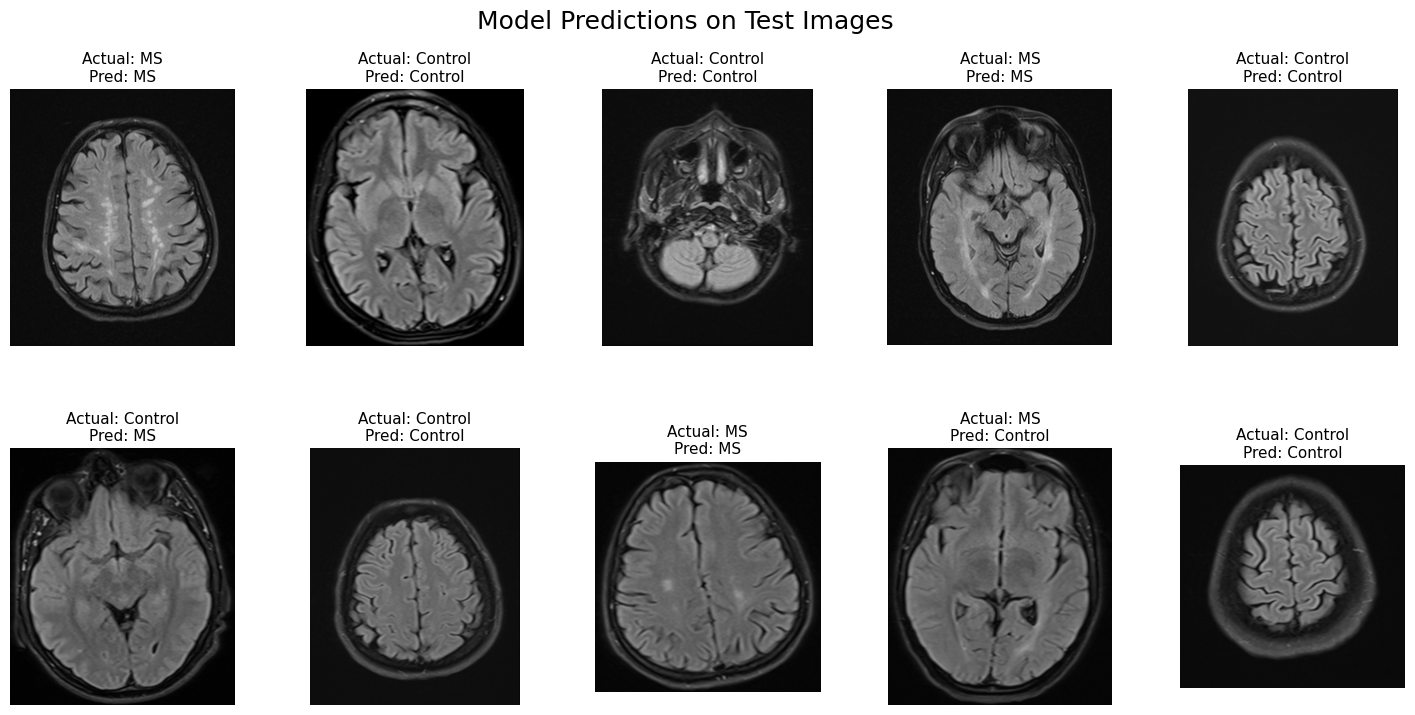

In [10]:
X_test, y_test = test_data
evaluator.predict_model(model, X_test, y_test, test_transform)